In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ekowannanindome/stellar-dataset/sample_submission.csv
/kaggle/input/datasets/ekowannanindome/stellar-dataset/train.csv
/kaggle/input/datasets/ekowannanindome/stellar-dataset/test.csv


## 1. Imports & Config

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
import optuna

from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score, classification_report

optuna.logging.set_verbosity(optuna.logging.WARNING)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

In [3]:
CFG = dict(
    n_folds         = 5,
    seed            = 42,
    # Optuna search
    optuna_trials   = 50,
    optuna_folds    = 3,
    optuna_sample   = 0.3,   # fraction of train used during search
    # Final model
    n_estimators    = 2000,
    early_stop      = 50,
)

BASELINE_OOF = 0.96418
BASELINE_LB  = 0.96509

## 2. Load Data

In [4]:
train = pd.read_csv('/kaggle/input/datasets/ekowannanindome/stellar-dataset/train.csv', index_col='id')
test  = pd.read_csv('/kaggle/input/datasets/ekowannanindome/stellar-dataset/test.csv',  index_col='id')

print(f'Train: {train.shape}  |  Test: {test.shape}')

Train: (577347, 11)  |  Test: (247435, 10)


## 3. Feature Engineering

New features on top of v1 color indices:
- `log_redshift` — log1p transform; better model resolution at the low end where STAR/GALAXY confusion is
- `redshift_sq` — captures non-linearity around the STAR boundary
- `redshift × g_r`, `redshift × u_g`, `redshift × g_i` — the STAR locus in color space shifts with redshift for galaxies/QSOs but not for stars
- `u_z` — widest color baseline across all filters

In [5]:
def engineer_features(df):
    df = df.copy()

    # v1 color indices
    df['u_g'] = df['u'] - df['g']
    df['g_r'] = df['g'] - df['r']
    df['r_i'] = df['r'] - df['i']
    df['i_z'] = df['i'] - df['z']
    df['u_r'] = df['u'] - df['r']
    df['g_i'] = df['g'] - df['i']
    df['g_z'] = df['g'] - df['z']

    # v2 additions
    df['u_z']          = df['u'] - df['z']                  # widest color baseline
    df['log_redshift'] = np.log1p(df['redshift'])            # compress skewed tail
    df['redshift_sq']  = df['redshift'] ** 2                 # non-linearity near zero
    df['rs_x_gr']      = df['redshift'] * df['g_r']          # color-redshift interaction
    df['rs_x_ug']      = df['redshift'] * df['u_g']
    df['rs_x_gi']      = df['redshift'] * df['g_i']

    return df

train = engineer_features(train)
test  = engineer_features(test)

V1_COLOR_COLS = ['u_g', 'g_r', 'r_i', 'i_z', 'u_r', 'g_i', 'g_z']
V2_FEAT_COLS  = ['u_z', 'log_redshift', 'redshift_sq', 'rs_x_gr', 'rs_x_ug', 'rs_x_gi']

print(f'Total new features added: {len(V2_FEAT_COLS)}')
print(train[V2_FEAT_COLS].describe().round(3))

Total new features added: 6
              u_z  log_redshift  redshift_sq     rs_x_gr     rs_x_ug  \
count 577347.0000   577347.0000  577347.0000 577347.0000 577347.0000   
mean       3.4010        0.4640       1.1790      0.5780      0.8210   
std        1.9350        0.3740       2.9690      0.7420      1.4580   
min      -19.9990       -0.0100       0.0000    -20.1360   -113.8310   
25%        1.6610        0.1660       0.0330      0.0780      0.1080   
50%        3.5670        0.4040       0.2480      0.4330      0.4560   
75%        4.7800        0.6320       0.7770      0.9130      1.0700   
max       10.4070        2.0810      49.1510     27.3390     30.8580   

          rs_x_gi  
count 577347.0000  
mean       0.9260  
std        1.0770  
min      -13.3410  
25%        0.1510  
50%        0.6970  
75%        1.4320  
max       36.1890  


## 4. Preprocessing

In [6]:
CAT_COLS  = ['spectral_type', 'galaxy_population']
NUM_COLS  = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']
FEAT_COLS = NUM_COLS + V1_COLOR_COLS + V2_FEAT_COLS + CAT_COLS
TARGET    = 'class'

oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
train[CAT_COLS] = oe.fit_transform(train[CAT_COLS])
test[CAT_COLS]  = oe.transform(test[CAT_COLS])

le = LabelEncoder()
y  = le.fit_transform(train[TARGET])
print('Class mapping:', dict(zip(le.classes_, le.transform(le.classes_))))

X      = train[FEAT_COLS]
X_test = test[FEAT_COLS]
print(f'\nFeature matrix: {X.shape}')

Class mapping: {'GALAXY': np.int64(0), 'QSO': np.int64(1), 'STAR': np.int64(2)}

Feature matrix: (577347, 23)


## 5. Optuna Hyperparameter Search

Run on a stratified 30% sample with 3-fold CV to keep wall time reasonable.  
We use `balanced_accuracy_score` as the objective since that's the competition metric.

In [7]:
from sklearn.model_selection import train_test_split

# Stratified sample for Optuna
_, X_opt, _, y_opt = train_test_split(
    X, y,
    test_size=CFG['optuna_sample'],
    stratify=y,
    random_state=CFG['seed'],
)
print(f'Optuna search set: {X_opt.shape}')

def objective(trial):
    params = dict(
        n_estimators      = 500,
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        num_leaves        = trial.suggest_int('num_leaves', 63, 511),
        min_child_samples = trial.suggest_int('min_child_samples', 20, 200),
        subsample         = trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.6, 1.0),
        reg_alpha         = trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        reg_lambda        = trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        class_weight      = 'balanced',
        n_jobs            = -1,
        random_state      = CFG['seed'],
        verbose           = -1,
    )

    skf = StratifiedKFold(n_splits=CFG['optuna_folds'], shuffle=True, random_state=CFG['seed'])
    scores = []
    for tr_idx, val_idx in skf.split(X_opt, y_opt):
        m = lgb.LGBMClassifier(**params)
        m.fit(
            X_opt.iloc[tr_idx], y_opt[tr_idx],
            eval_set=[(X_opt.iloc[val_idx], y_opt[val_idx])],
            callbacks=[lgb.early_stopping(30, verbose=False)],
            categorical_feature=CAT_COLS,
        )
        preds = le.inverse_transform(m.predict(X_opt.iloc[val_idx]))
        truth = le.inverse_transform(y_opt[val_idx])
        scores.append(balanced_accuracy_score(truth, preds))

    return np.mean(scores)

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=CFG['seed']))
study.optimize(objective, n_trials=CFG['optuna_trials'], show_progress_bar=True)

print(f'\nBest trial score: {study.best_value:.5f}')
print('Best params:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

Optuna search set: (173205, 23)


  0%|          | 0/50 [00:00<?, ?it/s]


Best trial score: 0.96208
Best params:
  learning_rate: 0.013580756602263475
  num_leaves: 97
  min_child_samples: 78
  subsample: 0.8542644524941999
  colsample_bytree: 0.6479144833269866
  reg_alpha: 3.4684004618244466e-07
  reg_lambda: 0.820068549511774


/tmp/ipykernel_58/3014048065.py:2: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study)


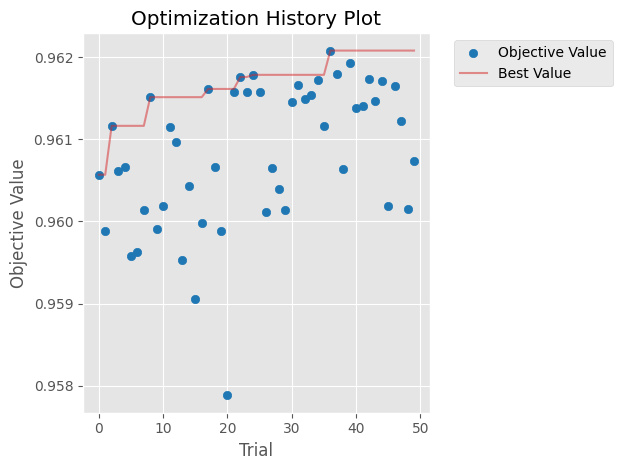

In [8]:
# Optuna optimization history
optuna.visualization.matplotlib.plot_optimization_history(study)
plt.tight_layout()

/tmp/ipykernel_58/1144836396.py:2: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_param_importances(study)


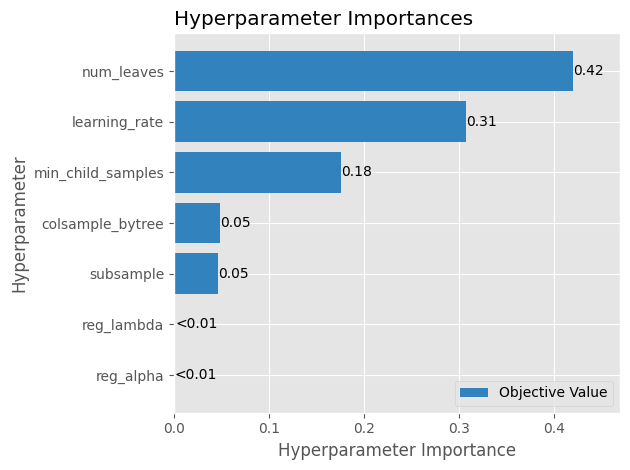

In [9]:
# Parameter importances
optuna.visualization.matplotlib.plot_param_importances(study)
plt.tight_layout()

## 6. Final Model — 5-Fold CV with Best Params

In [10]:
BEST_PARAMS = dict(
    **study.best_params,
    n_estimators  = CFG['n_estimators'],
    class_weight  = 'balanced',
    n_jobs        = -1,
    random_state  = CFG['seed'],
    verbose       = -1,
)

skf = StratifiedKFold(n_splits=CFG['n_folds'], shuffle=True, random_state=CFG['seed'])

oof_proba  = np.zeros((len(X), len(le.classes_)))
test_proba = np.zeros((len(X_test), len(le.classes_)))
fold_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]

    model = lgb.LGBMClassifier(**BEST_PARAMS)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(CFG['early_stop'], verbose=False),
            lgb.log_evaluation(200),
        ],
        categorical_feature=CAT_COLS,
    )

    val_proba = model.predict_proba(X_val)
    val_preds = le.inverse_transform(val_proba.argmax(axis=1))
    val_true  = le.inverse_transform(y_val)

    score = balanced_accuracy_score(val_true, val_preds)
    fold_scores.append(score)
    oof_proba[val_idx] = val_proba
    test_proba += model.predict_proba(X_test) / CFG['n_folds']

    print(f'  Fold {fold+1}/{CFG["n_folds"]} | best_iter={model.best_iteration_} | balanced_acc={score:.5f}')

print(f'\nCV mean: {np.mean(fold_scores):.5f}')
print(f'CV std:  {np.std(fold_scores):.5f}')

[200]	valid_0's multi_logloss: 0.152814
[400]	valid_0's multi_logloss: 0.116421
[600]	valid_0's multi_logloss: 0.109802
[800]	valid_0's multi_logloss: 0.107174
[1000]	valid_0's multi_logloss: 0.105379
[1200]	valid_0's multi_logloss: 0.103754
[1400]	valid_0's multi_logloss: 0.102582
[1600]	valid_0's multi_logloss: 0.10171
[1800]	valid_0's multi_logloss: 0.100845
[2000]	valid_0's multi_logloss: 0.100117
  Fold 1/5 | best_iter=2000 | balanced_acc=0.96583
[200]	valid_0's multi_logloss: 0.15511
[400]	valid_0's multi_logloss: 0.118768
[600]	valid_0's multi_logloss: 0.11196
[800]	valid_0's multi_logloss: 0.109632
[1000]	valid_0's multi_logloss: 0.107866
[1200]	valid_0's multi_logloss: 0.106271
[1400]	valid_0's multi_logloss: 0.104879
[1600]	valid_0's multi_logloss: 0.10389
[1800]	valid_0's multi_logloss: 0.102991
[2000]	valid_0's multi_logloss: 0.102224
  Fold 2/5 | best_iter=2000 | balanced_acc=0.96542
[200]	valid_0's multi_logloss: 0.157304
[400]	valid_0's multi_logloss: 0.12028
[600]	valid

## 7. OOF Evaluation

In [11]:
oof_preds_labels = le.inverse_transform(oof_proba.argmax(axis=1))
oof_true_labels  = le.inverse_transform(y)
oof_score = balanced_accuracy_score(oof_true_labels, oof_preds_labels)

print(f'OOF balanced accuracy : {oof_score:.5f}')
print(f'Baseline OOF          : {BASELINE_OOF:.5f}')
delta = oof_score - BASELINE_OOF
print(f'Delta vs baseline     : {"+" if delta >= 0 else ""}{delta:.5f}  {"✓ improvement" if delta > 0 else "✗ no improvement"}')

OOF balanced accuracy : 0.96514
Baseline OOF          : 0.96418
Delta vs baseline     : +0.00096  ✓ improvement


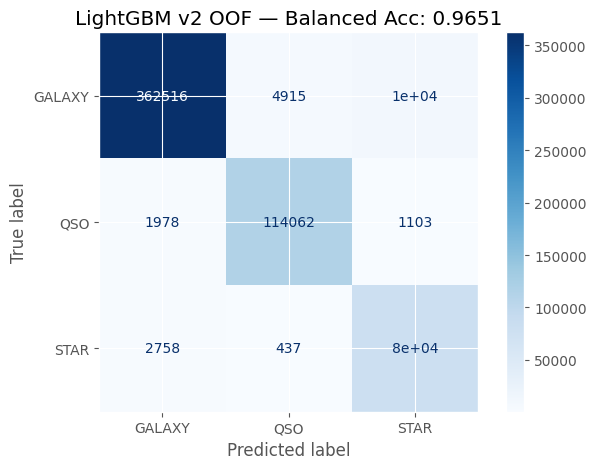

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

classes_ordered = ['GALAXY', 'QSO', 'STAR']

cm = confusion_matrix(oof_true_labels, oof_preds_labels, labels=classes_ordered)
ConfusionMatrixDisplay(cm, display_labels=classes_ordered).plot(cmap='Blues')
plt.title(f'LightGBM v2 OOF — Balanced Acc: {oof_score:.4f}')
plt.tight_layout()

In [13]:
# Per-class breakdown — focus on STAR precision vs baseline (was 0.89)
print(classification_report(oof_true_labels, oof_preds_labels, target_names=classes_ordered))

              precision    recall  f1-score   support

      GALAXY       0.99      0.96      0.97    377480
         QSO       0.96      0.97      0.96    117143
        STAR       0.88      0.96      0.92     82724

    accuracy                           0.96    577347
   macro avg       0.94      0.97      0.95    577347
weighted avg       0.96      0.96      0.96    577347



## 8. Feature Importance

          feature  importance
            alpha       58909
            delta       58207
              r_i       29668
              g_z       29330
              i_z       29058
                r       26844
                u       26320
              u_g       26306
                z       26087
              u_z       25540
                g       24915
         redshift       24785
              u_r       24543
                i       24254
              g_i       24060
              g_r       23468
          rs_x_ug       22527
          rs_x_gr       21278
          rs_x_gi       21201
      redshift_sq       18927
     log_redshift        8733
    spectral_type         305
galaxy_population         159


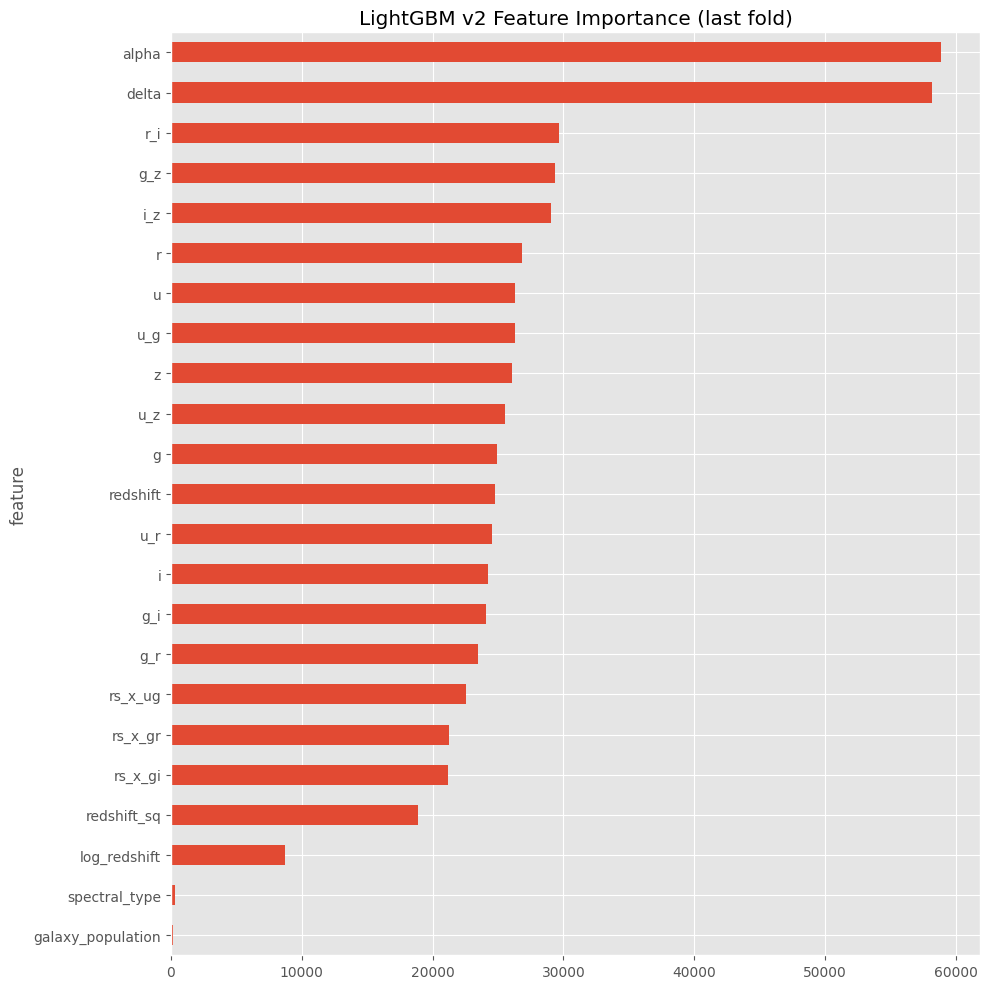

In [14]:
importance_df = pd.DataFrame({
    'feature':    X.columns,
    'importance': model.feature_importances_,
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 10))
importance_df.plot.barh(x='feature', y='importance', ax=ax, legend=False)
ax.set_title('LightGBM v2 Feature Importance (last fold)')
ax.invert_yaxis()
plt.tight_layout()

print(importance_df.to_string(index=False))

## 9. Generate Submission

In [15]:
test_pred_labels = le.inverse_transform(test_proba.argmax(axis=1))

submission = pd.DataFrame({'id': test.index, 'class': test_pred_labels})
submission.to_csv('submission_lgbm_v2.csv', index=False)

print(f'Submission shape: {submission.shape}')
print(submission['class'].value_counts())
submission.head()

Submission shape: (247435, 2)
class
GALAXY    157602
QSO        51095
STAR       38738
Name: count, dtype: int64


,id,class
0,577347,GALAXY
1,577348,GALAXY
2,577349,GALAXY
3,577350,STAR
4,577351,GALAXY


In [16]:
from IPython.display import FileLink, display

display(FileLink('submission_lgbm_v2.csv'))

/kaggle/working/submission_lgbm_v2.csv